<a href="https://colab.research.google.com/github/dglloyde/uk-air-quality-analysis/blob/main/notebooks/P1_air_quality_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Loading the Data

In [14]:
from google.colab import files
uploaded = files.upload()

Saving PiccadillyAirQualityDataHourly.csv to PiccadillyAirQualityDataHourly.csv


In [41]:
import pandas as pd

rawAQD = pd.read_csv('PiccadillyAirQualityDataHourly.csv', skiprows=10)

## Overview of Raw Data

In [36]:
rawAQD.head(60)

,date,time,no2,status
0,2018-01-01,01:00:00,37.57883,V ugm-3
1,2018-01-01,02:00:00,25.35174,V ugm-3
2,2018-01-01,03:00:00,18.03759,V ugm-3
3,2018-01-01,04:00:00,23.24502,V ugm-3
4,2018-01-01,05:00:00,23.04107,V ugm-3
5,2018-01-01,06:00:00,19.01839,V ugm-3
6,2018-01-01,07:00:00,16.18447,V ugm-3
7,2018-01-01,08:00:00,19.02126,V ugm-3
8,2018-01-01,09:00:00,22.42177,V ugm-3
9,2018-01-01,10:00:00,17.21377,V ugm-3


In [30]:
rawAQD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43825 entries, 0 to 43824
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              43825 non-null  object
 1   Time              43824 non-null  object
 2   Nitrogen dioxide  43824 non-null  object
 3   Status            43824 non-null  object
dtypes: object(4)
memory usage: 1.3+ MB


In [31]:
rawAQD.describe()

,Date,Time,Nitrogen dioxide,Status
count,43825,43824,43824,43824
unique,1827,24,42985,1
top,2022-12-31,01:00:00,No data,V ugm-3
freq,24,1826,652,43824


## Cleaning Data

In [42]:
rawAQD.columns = ["date", "time", "no2", "status"]

In [43]:
rawAQD['no2'] = pd.to_numeric(rawAQD['no2'], errors='coerce')
rawAQD = rawAQD[rawAQD['status'].isin(["V ugm-3"])]

In [44]:
print(f"Total rows: {len(rawAQD)}")
print(f"Missing NO2 values: {rawAQD['no2'].isna().sum()}")
print(f"That is {rawAQD['no2'].isna().mean()*100:.1f}% of the data")

Total rows: 43824
Missing NO2 values: 652
That is 1.5% of the data


### Creating Proper Time Index

In [45]:
mask_24 = rawAQD['time'] == '24:00:00'
rawAQD.loc[mask_24, 'time'] = '00:00:00'
rawAQD.loc[mask_24, 'date'] = (
    pd.to_datetime(rawAQD.loc[mask_24, 'date']) + pd.Timedelta(days=1)
).dt.strftime('%Y-%m-%d')

rawAQD['datetime'] = pd.to_datetime(rawAQD['date'] + ' ' + rawAQD['time'])
rawAQD = rawAQD.set_index('datetime')
rawAQD = rawAQD.drop(columns = ['date', 'time', 'status'])
rawAQD = rawAQD.sort_index()

In [53]:
cleanAQD = rawAQD.copy()
cleanAQD.to_csv('cleanAQD.csv')

In [46]:
rawAQD.head(30)

,no2
datetime,
2018-01-01 01:00:00,37.57883
2018-01-01 02:00:00,25.35174
2018-01-01 03:00:00,18.03759
2018-01-01 04:00:00,23.24502
2018-01-01 05:00:00,23.04107
2018-01-01 06:00:00,19.01839
2018-01-01 07:00:00,16.18447
2018-01-01 08:00:00,19.02126
2018-01-01 09:00:00,22.42177


## EDA

In [48]:
print(cleanAQD["no2"].describe())

count    43172.000000
mean        31.324369
std         17.865794
min          2.007220
25%         17.333845
50%         27.740895
75%         42.112930
max        159.577850
Name: no2, dtype: float64


In [50]:
cleanAQD['year'] = cleanAQD.index.year
print(cleanAQD.groupby('year')['no2'].describe().round(1))

       count  mean   std   min   25%   50%   75%    max
year                                                   
2018  8681.0  34.6  16.5   5.2  21.9  32.2  45.1  159.6
2019  8659.0  36.3  18.4   3.9  21.7  33.8  47.6  118.5
2020  8713.0  27.1  17.1   2.0  13.6  22.9  36.8  103.7
2021  8437.0  29.5  17.1   2.9  16.2  25.5  39.7  112.9
2022  8681.0  29.0  18.3   3.1  15.6  24.2  37.7  144.4
2023     1.0  23.2   NaN  23.2  23.2  23.2  23.2   23.2


### Distributions and Seasonality

In [51]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

/tmp/ipykernel_6425/3347597703.py:9: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_6425/3347597703.py:10: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_raw_timeseries.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


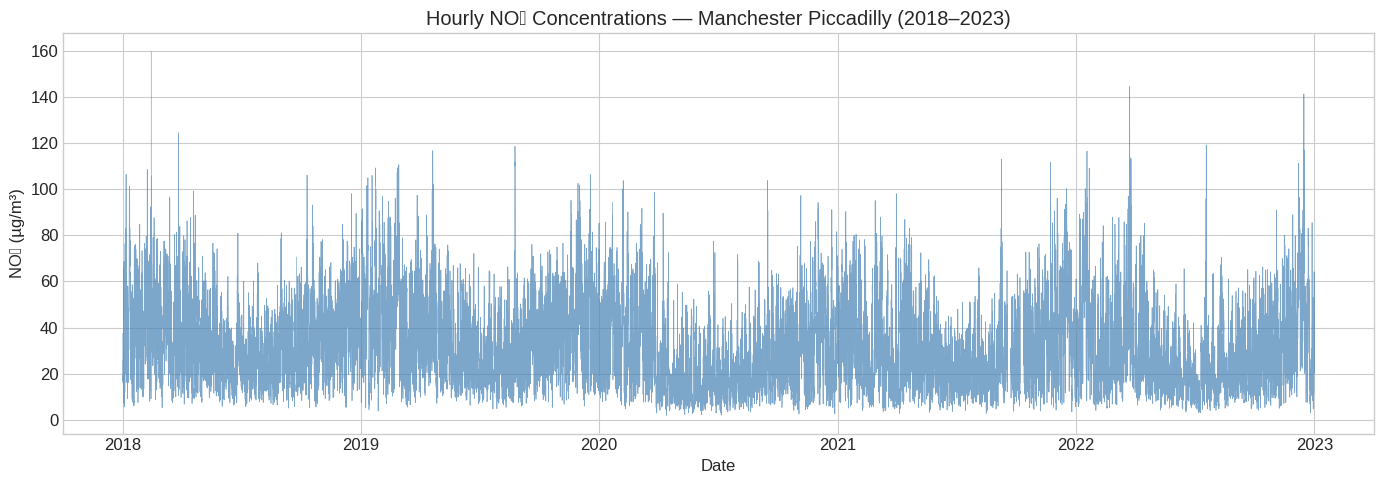

In [52]:
fig, ax = plt.subplots()

ax.plot(cleanAQD.index, cleanAQD['no2'], linewidth=0.5, color='steelblue', alpha=0.7)

ax.set_title('Hourly NO₂ Concentrations — Manchester Piccadilly (2018–2023)')
ax.set_xlabel('Date')
ax.set_ylabel('NO₂ (µg/m³)')

plt.tight_layout()
plt.savefig('no2_raw_timeseries.png', dpi=150)
plt.show()

/tmp/ipykernel_6425/1609254731.py:11: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_6425/1609254731.py:12: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_daily_mean.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


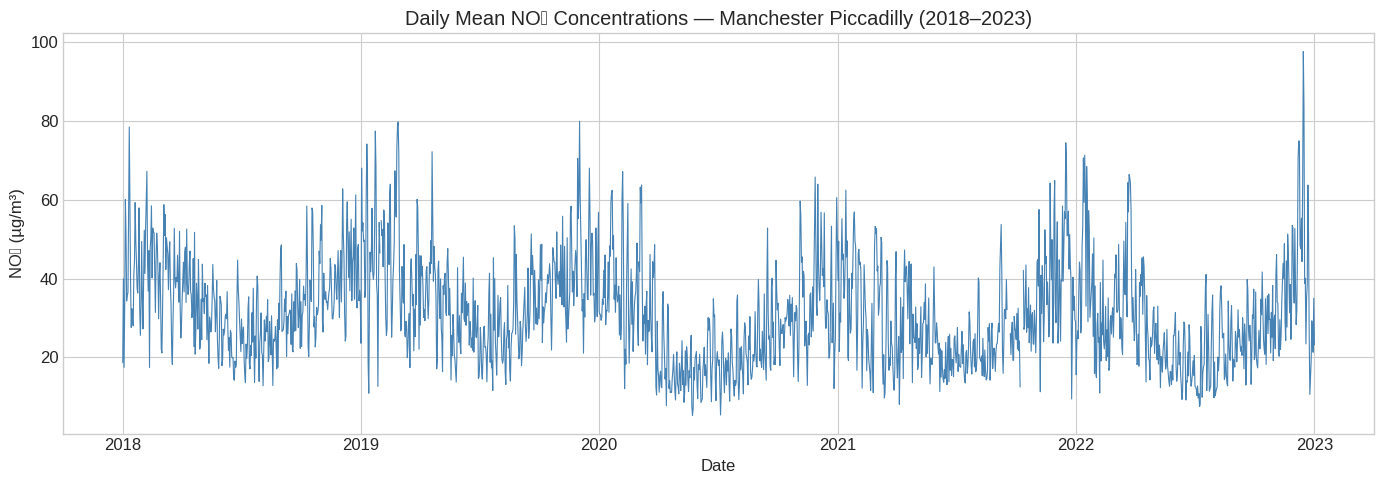

In [54]:
daily = cleanAQD['no2'].resample('D').mean()

fig, ax = plt.subplots()

ax.plot(daily.index, daily.values, linewidth=0.8, color='steelblue')

ax.set_title('Daily Mean NO₂ Concentrations — Manchester Piccadilly (2018–2023)')
ax.set_xlabel('Date')
ax.set_ylabel('NO₂ (µg/m³)')

plt.tight_layout()
plt.savefig('no2_daily_mean.png', dpi=150)
plt.show()

/tmp/ipykernel_6425/2394836278.py:11: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_6425/2394836278.py:12: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_distribution.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


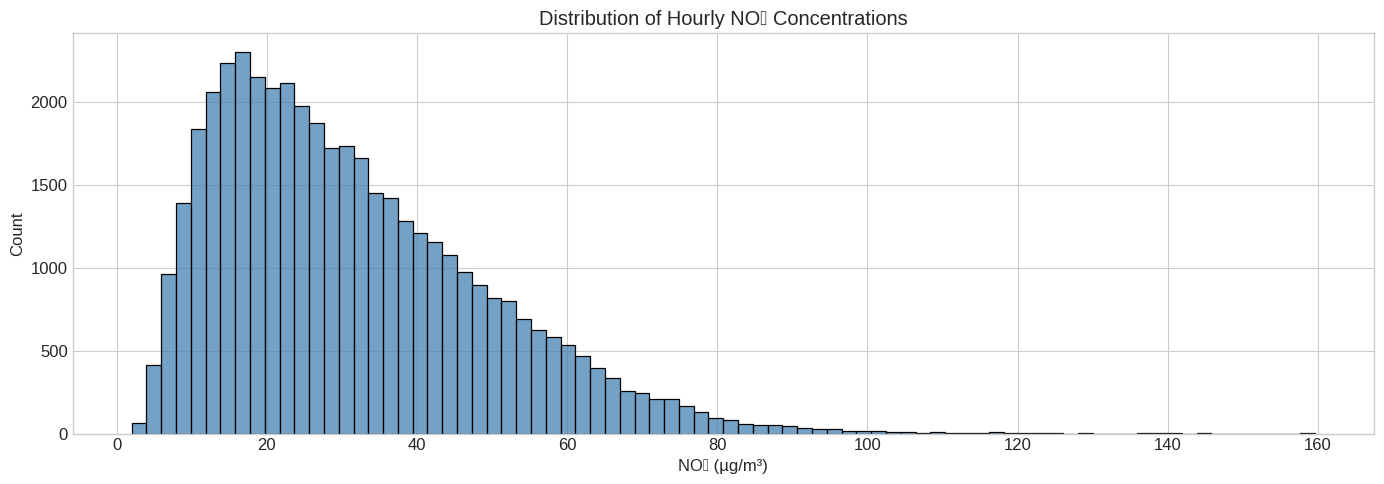

In [55]:
import seaborn as sns

fig, ax = plt.subplots()

sns.histplot(cleanAQD['no2'].dropna(), bins=80, color='steelblue', ax=ax)

ax.set_title('Distribution of Hourly NO₂ Concentrations')
ax.set_xlabel('NO₂ (µg/m³)')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('no2_distribution.png', dpi=150)
plt.show()

/tmp/ipykernel_6425/554924950.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_6425/554924950.py:16: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_monthly.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


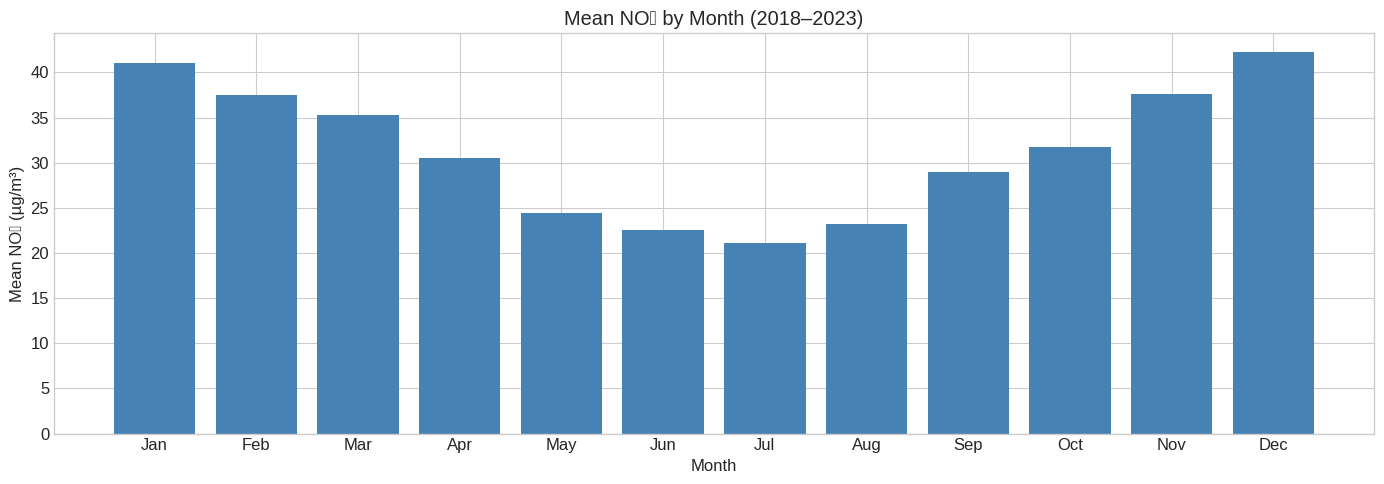

In [56]:
cleanAQD['month'] = cleanAQD.index.month

monthly_means = cleanAQD.groupby('month')['no2'].mean()

fig, ax = plt.subplots()

ax.bar(monthly_means.index, monthly_means.values, color='steelblue')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Mean NO₂ by Month (2018–2023)')
ax.set_xlabel('Month')
ax.set_ylabel('Mean NO₂ (µg/m³)')

plt.tight_layout()
plt.savefig('no2_monthly.png', dpi=150)

/tmp/ipykernel_6425/2864556408.py:14: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_6425/2864556408.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_hourly.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


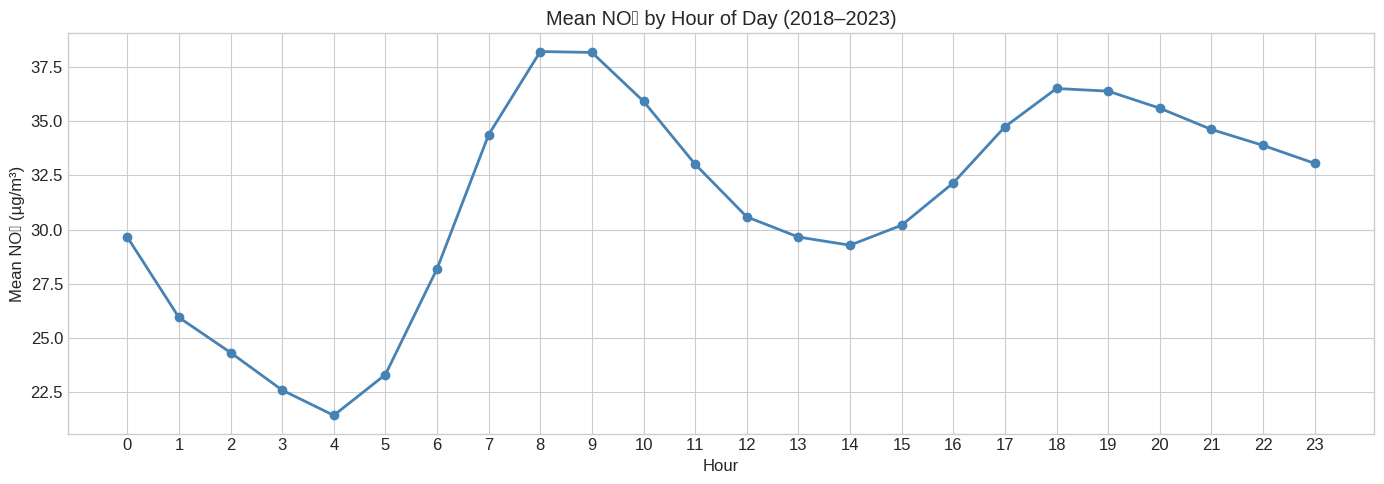

In [57]:
cleanAQD['hour'] = cleanAQD.index.hour

hourly_means = cleanAQD.groupby('hour')['no2'].mean()

fig, ax = plt.subplots()

ax.plot(hourly_means.index, hourly_means.values,
        marker='o', color='steelblue', linewidth=2)
ax.set_title('Mean NO₂ by Hour of Day (2018–2023)')
ax.set_xlabel('Hour')
ax.set_ylabel('Mean NO₂ (µg/m³)')
ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('no2_hourly.png', dpi=150)
plt.show()

### Outliers and Anomalies

In [58]:
mean = cleanAQD['no2'].mean()
std = cleanAQD['no2'].std()
threshold = mean + 3 * std

outliers = cleanAQD[cleanAQD['no2'] > threshold]

print(f"Mean NO₂: {mean:.1f} µg/m³")
print(f"Standard deviation: {std:.1f} µg/m³")
print(f"Outlier threshold (mean + 3σ): {threshold:.1f} µg/m³")
print(f"Number of outliers flagged: {len(outliers)}")
print(f"\nTop 10 highest readings:")
print(cleanAQD['no2'].nlargest(10))

Mean NO₂: 31.3 µg/m³
Standard deviation: 17.9 µg/m³
Outlier threshold (mean + 3σ): 84.9 µg/m³
Number of outliers flagged: 352

Top 10 highest readings:
datetime
2018-02-13 13:00:00    159.57785
2022-03-23 21:00:00    144.43189
2022-12-15 20:00:00    141.23230
2022-12-15 21:00:00    140.50603
2022-12-15 19:00:00    139.38832
2022-12-15 22:00:00    137.05487
2022-12-15 18:00:00    128.15315
2018-03-27 08:00:00    124.36468
2022-12-15 17:00:00    123.72048
2022-12-15 23:00:00    122.34230
Name: no2, dtype: float64


/tmp/ipykernel_6425/1096461604.py:13: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_6425/1096461604.py:14: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_outliers.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


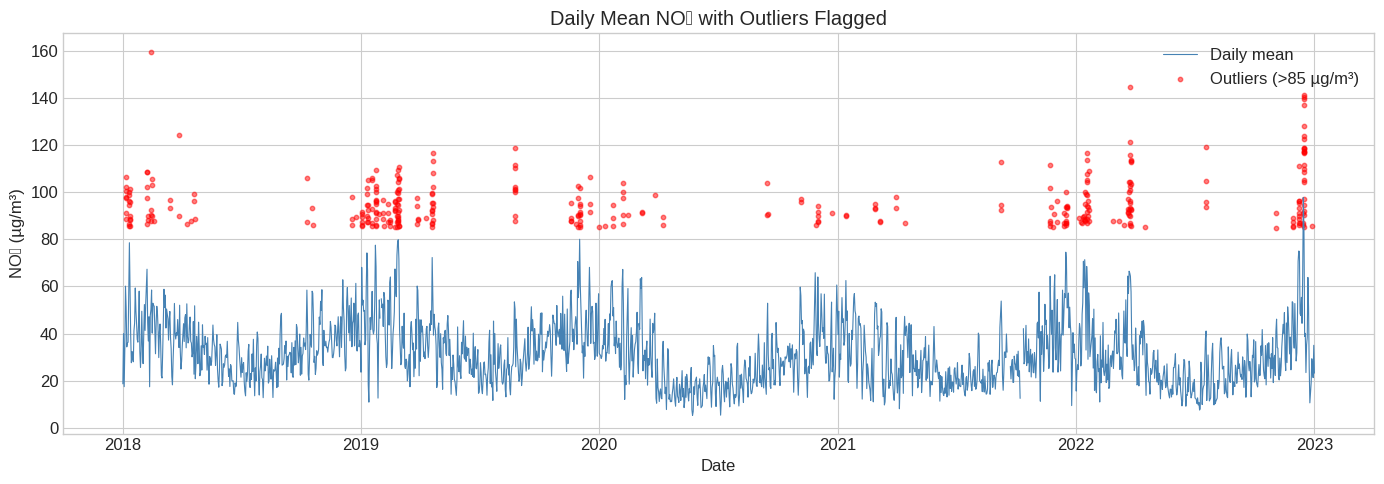

In [59]:
fig, ax = plt.subplots()

ax.plot(daily.index, daily.values, linewidth=0.8,
        color='steelblue', label='Daily mean')
ax.scatter(outliers.index, outliers['no2'],
           color='red', s=10, alpha=0.5, label=f'Outliers (>{threshold:.0f} µg/m³)')

ax.set_title('Daily Mean NO₂ with Outliers Flagged')
ax.set_xlabel('Date')
ax.set_ylabel('NO₂ (µg/m³)')
ax.legend()

plt.tight_layout()
plt.savefig('no2_outliers.png', dpi=150)
plt.show()